In [1]:
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np

In [2]:
def draw_landmarks_on_image(rgb_image, detection_result):
    pose_landmarks_list = detection_result.pose_landmarks
    annotated_image = np.copy(rgb_image)

    # 循环可视化姿势
    for idx in range(len(pose_landmarks_list)):
        pose_landmarks = pose_landmarks_list[idx]

        # 绘制姿势标记点
        pose_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        pose_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in pose_landmarks
        ])
        solutions.drawing_utils.visualize_landmarks(
            annotated_image, 
            pose_landmarks_proto,
            solutions.pose.POSE_CONNECTIONS,
            solutions.drawing_styles.get_default_pose_landmarks_style()
        )
    return annotated_image

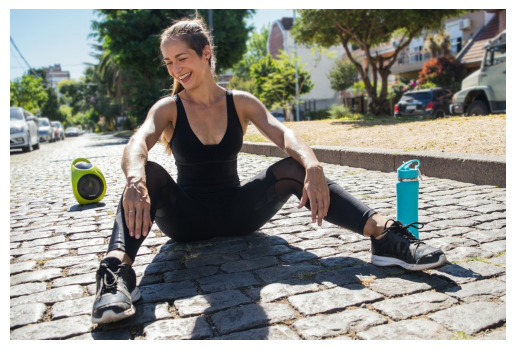

In [3]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread("/Users/wangshuaibo/Downloads/girl-4051811_960_720.jpg")

img = cv2.imread("/Users/wangshuaibo/Downloads/girl-4051811_960_720.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 将BGR图像转换为RGB图像

plt.imshow(img)
plt.axis("off")  # 关闭坐标轴
plt.show()

## 运行推理并可视化结果

In [7]:
# 1. 运行必要的包
import mediapipe as mp 
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 2. 创建姿势点识别
base_options = python.BaseOptions(model_asset_path='/Users/wangshuaibo/Downloads/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options = base_options,
    output_segmentation_mask=True
)
detector = vision.PoseLandmarker.creat_from_options(options)

#3. 加载输入的图像
image = mp.Image.creat_from_file("/Users/wangshuaibo/Downloads/girl-4051811_960_720.jpg")

#4. 进行图像识别
detection_result = detector.detect(image)

#5. 处理图像识别结果，此处为可视化
annoted_image = draw_landmarks_on_image(image.numpy_view(), detection_result)
cv2.imshow(cv2.cvtColor(annoted_image, cv2.COLOR.RGB2BRG))

TypeError: __init__() got an unexpected keyword argument 'output_segmentation_mask'

In [5]:
mp.__version__

'0.10.7'